In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Style
sns.set(style='whitegrid')

In [2]:
df = pd.read_csv("customer_churn_dataset-testing-master.csv")

# First 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [3]:
# Shape
print("Dataset Shape:", df.shape)

# Columns
print("\nColumns:\n", df.columns)

# Info
df.info()

Dataset Shape: (64374, 12)

Columns:
 Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency',
       'Support Calls', 'Payment Delay', 'Subscription Type',
       'Contract Length', 'Total Spend', 'Last Interaction', 'Churn'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn          

In [4]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
Usage Frequency      0
Support Calls        0
Payment Delay        0
Subscription Type    0
Contract Length      0
Total Spend          0
Last Interaction     0
Churn                0
dtype: int64

In [5]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Check duplicates removed
print("New Shape:", df.shape)

New Shape: (64374, 12)


In [6]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


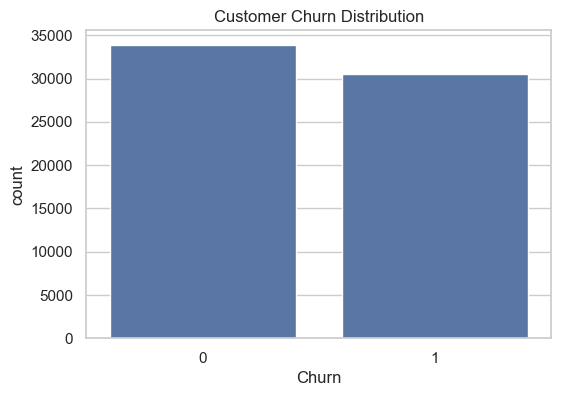

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

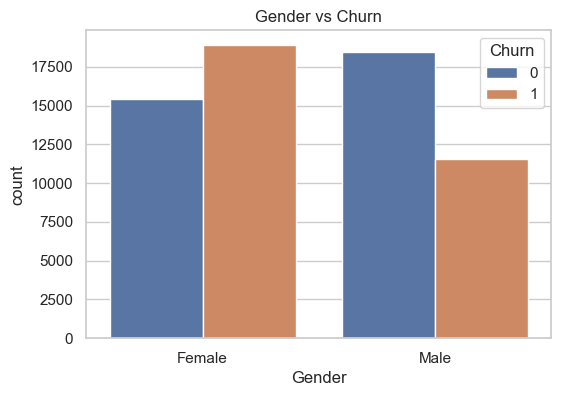

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(x='Gender', hue='Churn', data=df)

plt.title("Gender vs Churn")
plt.show()

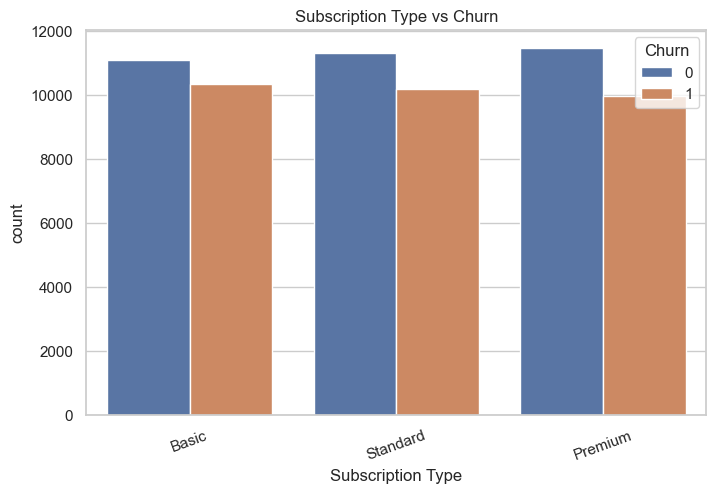

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(x='Subscription Type', hue='Churn', data=df)

plt.title("Subscription Type vs Churn")
plt.xticks(rotation=20)

plt.show()

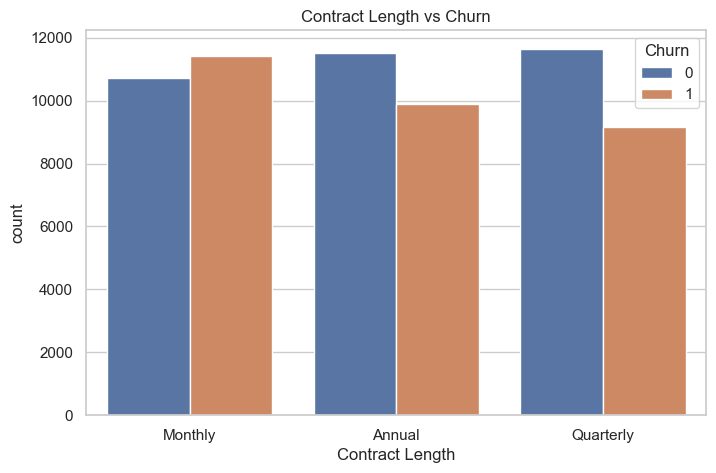

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract Length', hue='Churn', data=df)

plt.title("Contract Length vs Churn")

plt.show()

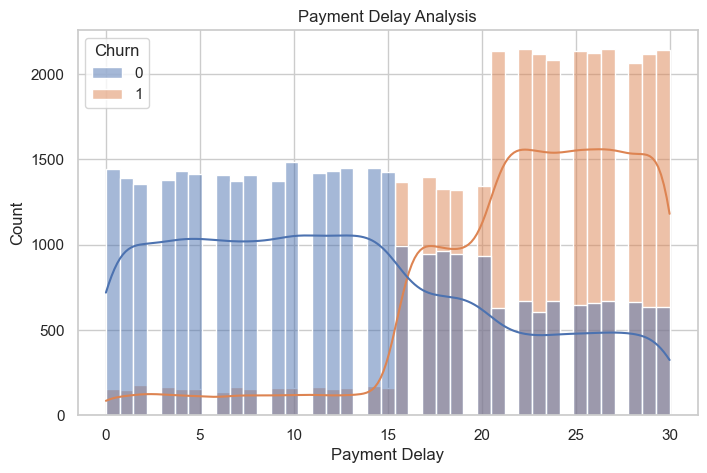

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Payment Delay', hue='Churn', kde=True)

plt.title("Payment Delay Analysis")

plt.show()

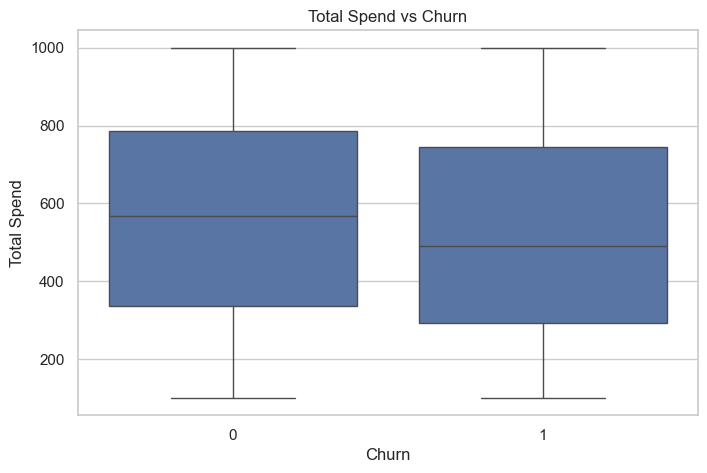

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Total Spend', data=df)

plt.title("Total Spend vs Churn")

plt.show()

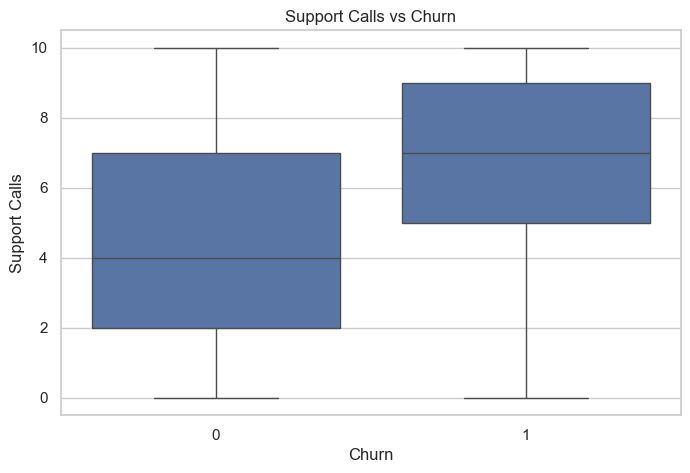

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='Support Calls', data=df)

plt.title("Support Calls vs Churn")

plt.show()

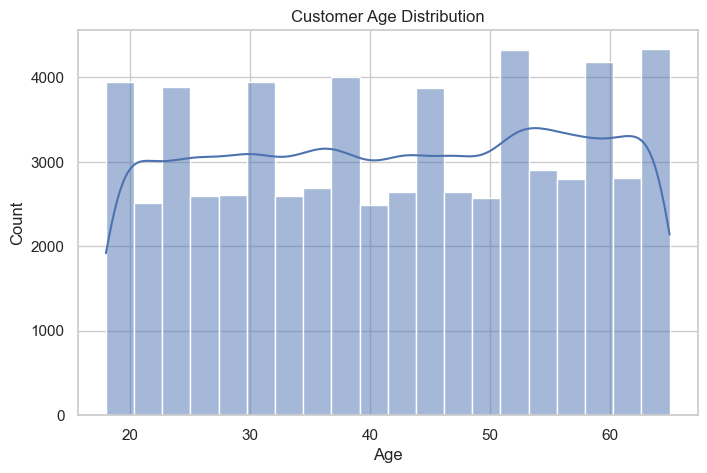

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Customer Age Distribution")

plt.show()

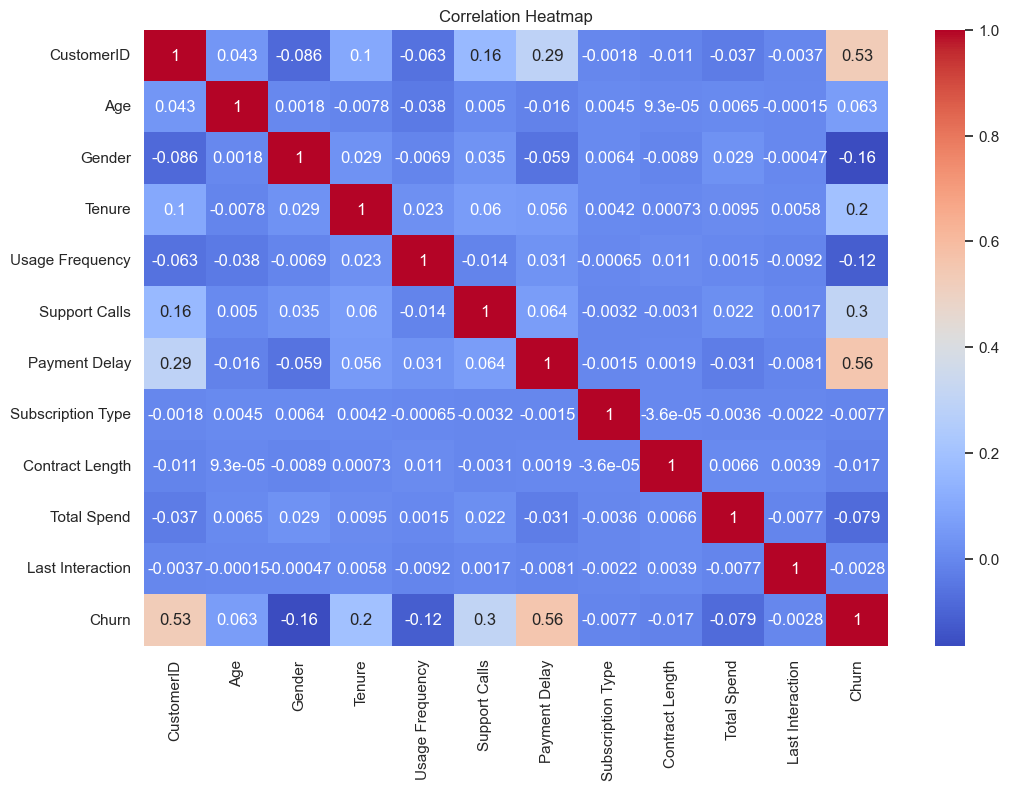

In [15]:
# Convert categorical columns into numeric

df_encoded = df.copy()

for col in df_encoded.columns:
    if df_encoded[col].dtype == 'object':
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [16]:
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print(churn_rate)

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


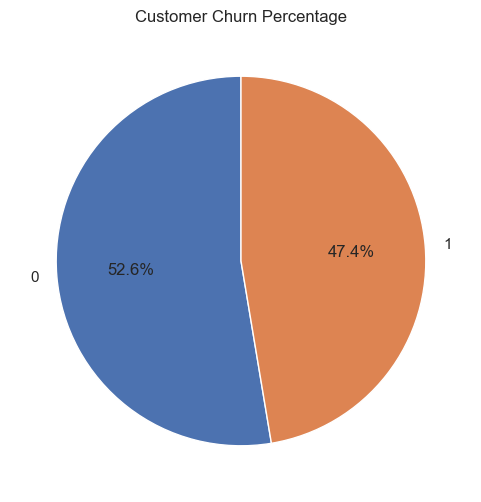

In [18]:
churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

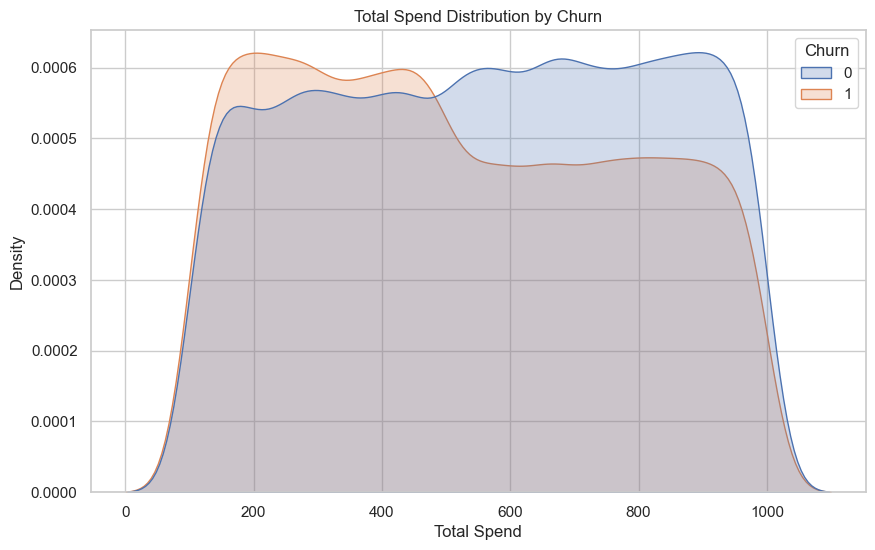

In [19]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    data=df,
    x='Total Spend',
    hue='Churn',
    fill=True
)

plt.title("Total Spend Distribution by Churn")

plt.show()

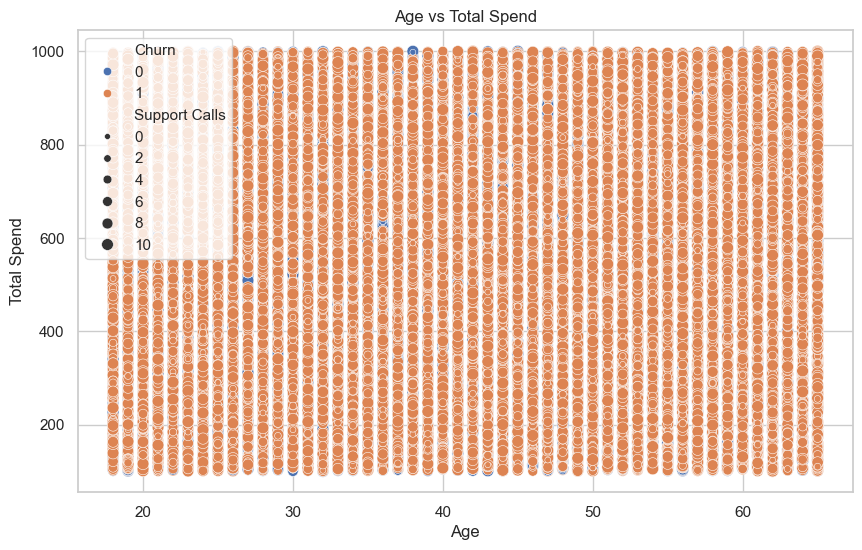

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Total Spend',
    hue='Churn',
    size='Support Calls'
)

plt.title("Age vs Total Spend")

plt.show()

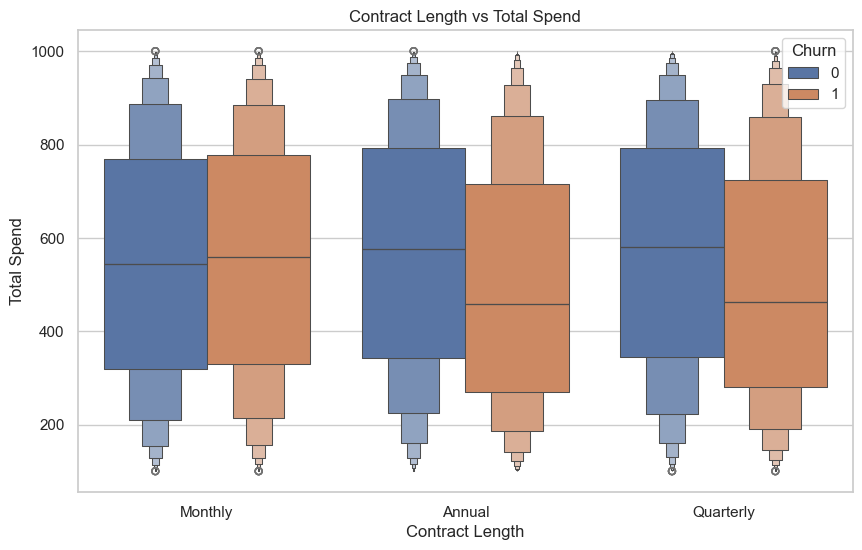

In [22]:
plt.figure(figsize=(10,6))

sns.boxenplot(
    x='Contract Length',
    y='Total Spend',
    hue='Churn',
    data=df
)

plt.title("Contract Length vs Total Spend")

plt.show()

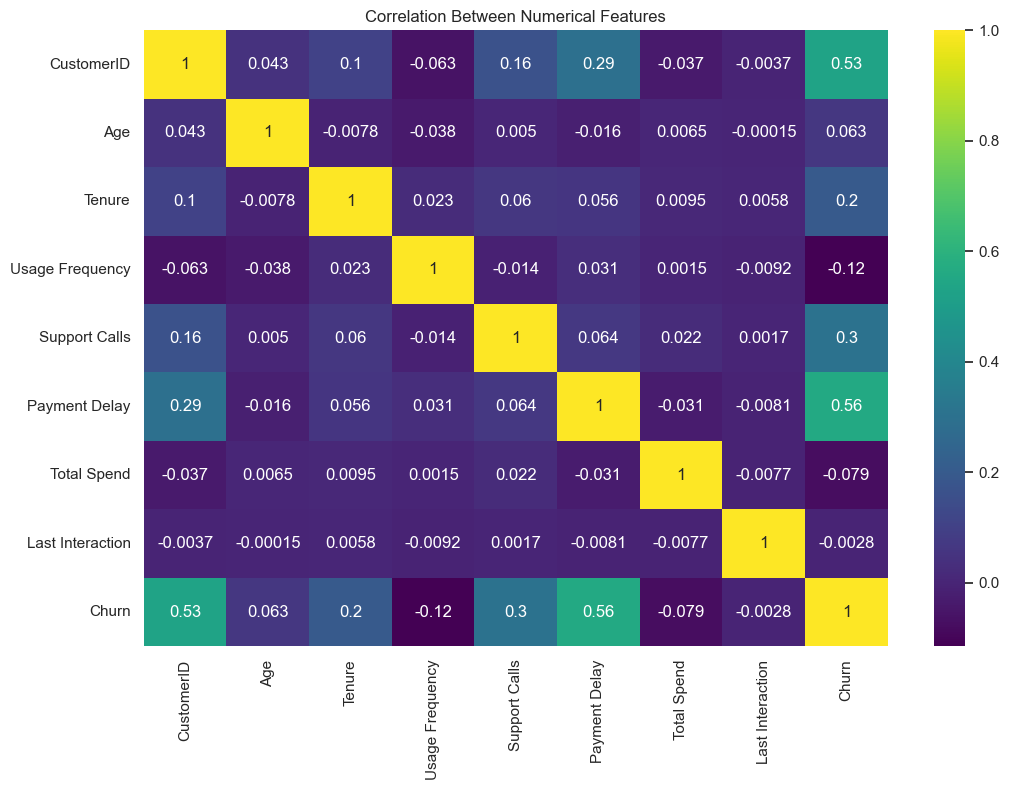

In [23]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='viridis'
)

plt.title("Correlation Between Numerical Features")

plt.show()

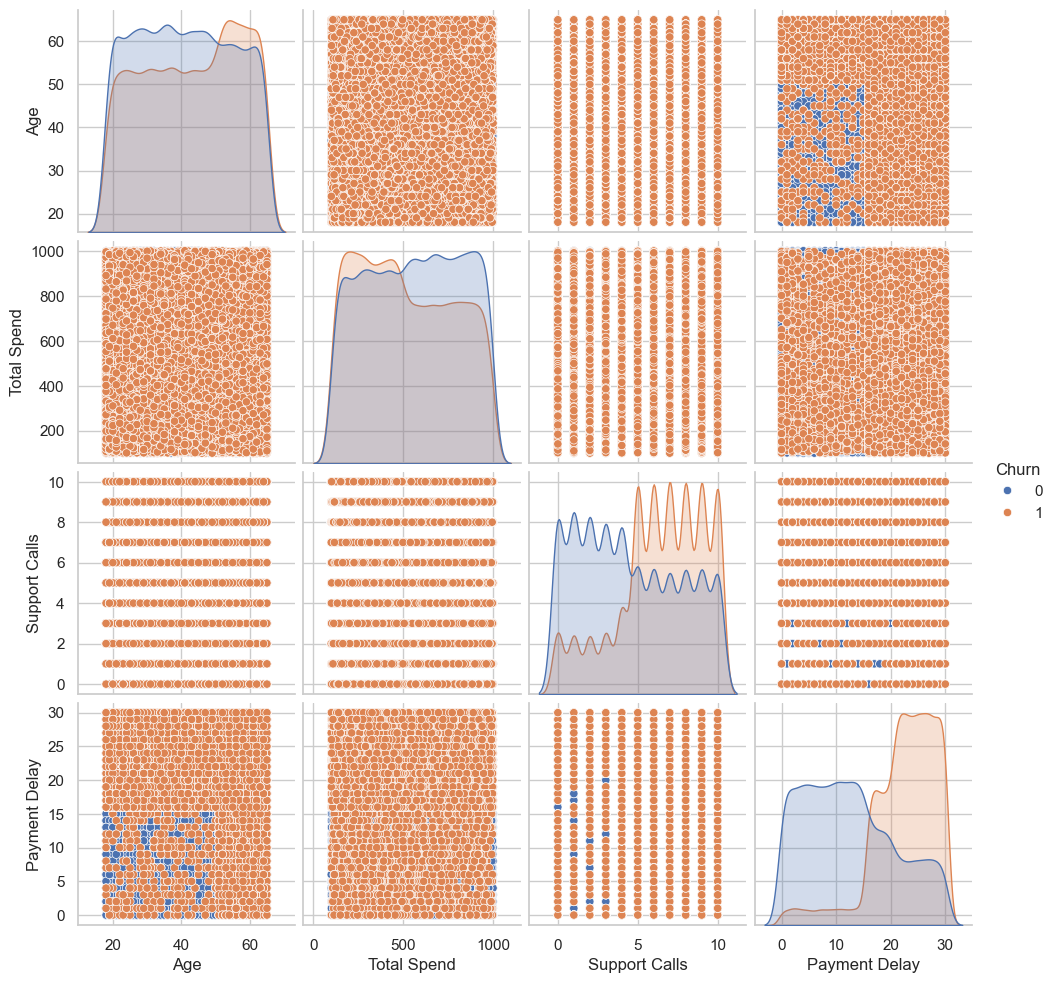

In [24]:
selected_columns = [
    'Age',
    'Total Spend',
    'Support Calls',
    'Payment Delay',
    'Churn'
]

sns.pairplot(
    df[selected_columns],
    hue='Churn'
)

plt.show()

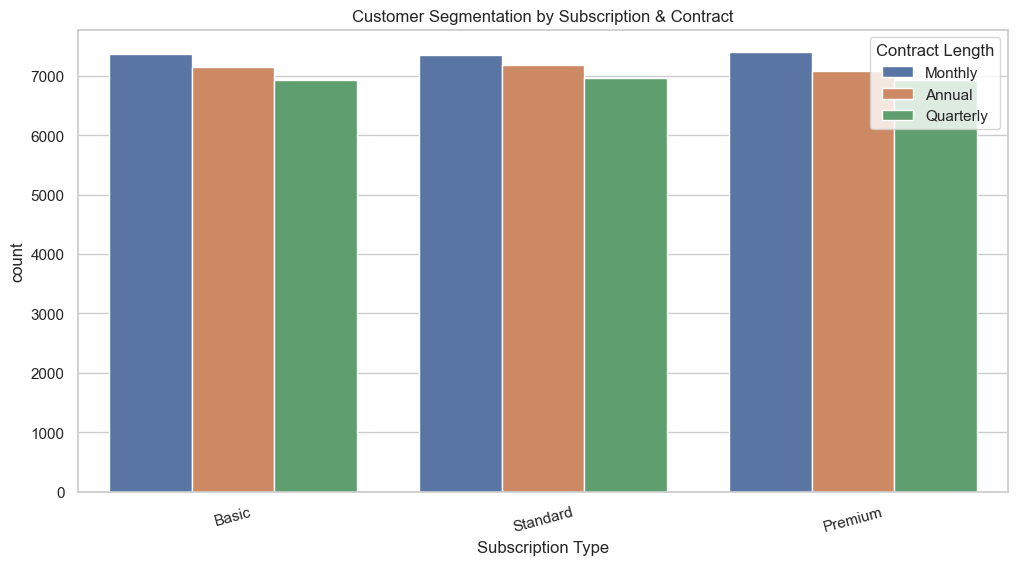

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Subscription Type',
    hue='Contract Length',
    data=df
)

plt.title("Customer Segmentation by Subscription & Contract")

plt.xticks(rotation=15)

plt.show()

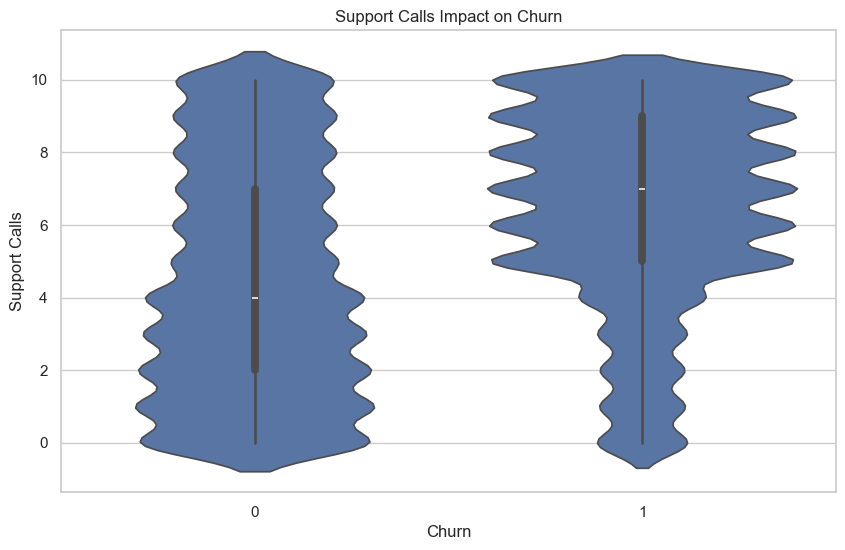

In [26]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Churn',
    y='Support Calls',
    data=df
)

plt.title("Support Calls Impact on Churn")

plt.show()